**Exercícios de Aprendizado Supervisionado**

In [98]:
#Importando bibliotecas necessárias

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_text

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,precision_score

from sklearn.model_selection import cross_val_score


**Download Dataset** - [Crop recommendation data](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/4GBWFV)

O dataset **Crop Recommendation Data** contém um total de 1697 amostras, referente as características de solo e condições ambientais para o crescimento de diversas culturas.

Os dados estão estruturados nas seguintes colunas:
N (Nitrogênio): Quantidade de nitrogênio no solo.

*   P (Fósforo): Quantidade de fósforo no solo
*   K (Potássio): Quantidade de potássio no solo
*   temperature (Temperatura): Temperatura ambiente em graus Celsius
*   humidity (Umidade): Umidade relativa do ar em porcentagem
ph: Valor de pH do solo
*   rainfall (Precipitação): Quantidade de precipitação em mm
*   label: A cultura recomendada para plantio, com base nas condições descritas


**Importante:** em *label*, temos os rótulos (classes) que representam diferentes culturas agrícolas: Rice (Arroz), Maize (Milho), Soyabeans (Soja), Beans (Feijão), Peas (Ervilhas), Groundnuts (Amendoins), Cowpeas (Feijão-caupi), Banana, Mango (Manga), Grapes (Uvas), Watermelon (Melancia), Apple (Maçã), Orange (Laranja), Cotton (Algodão) e Coffee (Café)

**Exercício 1 – Leitura Dataset**

Realize a leitura dos dados e exiba as informações gerais do dataset

Exiba quantas amostras existem por classe (label)


In [10]:
df = pd.read_csv('crop_recommendation.csv')
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000,1697.000000
mean,52.647024,58.126105,52.031232,24.711674,65.848856,6.438962,99.364935
std,38.536964,34.164342,57.068796,4.910428,24.432640,0.870411,50.436396
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,5.314507
25%,21.000000,36.000000,19.000000,21.631491,51.278688,5.861399,66.838723
50%,37.000000,54.000000,27.000000,24.910323,77.906210,6.354007,93.123306
75%,90.000000,72.000000,52.000000,27.834871,83.856427,6.932537,115.356032
max,140.000000,145.000000,205.000000,41.948657,94.964199,9.935091,298.560117


In [17]:
df['label'].describe()

,label
count,1697
unique,15
top,rice
freq,139


**Exercício 2 – Preparação dos Dados, divisão treinamento e testes**

Realize a divisão dos dados em treinamento e testes

In [62]:
X = df.drop(columns=['label'])
Y = df['label']

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

**Exercício 3 – Treinamento do Modelo (pode ser o K-NN ou Decision Tree)**

Escolha um algoritmo da biblioteca Scikit-learn que seja adequado para treinar um modelo de recomendação de plantio a partir das variaveis presentes no conjunto de dados.

**Utilizando Decision Tree**

In [170]:
tree_classification = DecisionTreeClassifier(random_state=42, max_depth=7)
tree_classification.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

**Exercício 4 – Avaliar o Modelo**

Utilize a métrica adequada para avaliar o modelo a partir dos dados de treinamento

In [171]:
# Para medir o quanto o modelo explica os dados
y_pred = tree_classification.predict(X_test)

train_accuracy = accuracy_score(y_train, tree_classification.predict(X_train))
print(f"Acurácia no Treinamento: {train_accuracy:.2f}")

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia no Teste: {test_accuracy:.2f}")

Acurácia no Treinamento: 1.00
Acurácia no Teste: 1.00


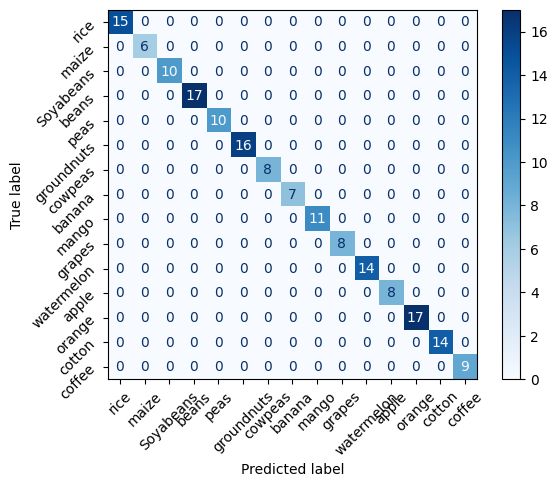

In [172]:
# Caso o modelo esteja se confundindo podemos validar aqui
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=Y.unique())
cm_display.plot(cmap='Blues')
plt.xticks(rotation=45)  # Rótulos do eixo x rotacionados para 45 graus
plt.yticks(rotation=45)  # Rótulos do eixo y rotacionados para 45 graus
plt.show()

Visualizar a árvore de decisão em forma de grafico

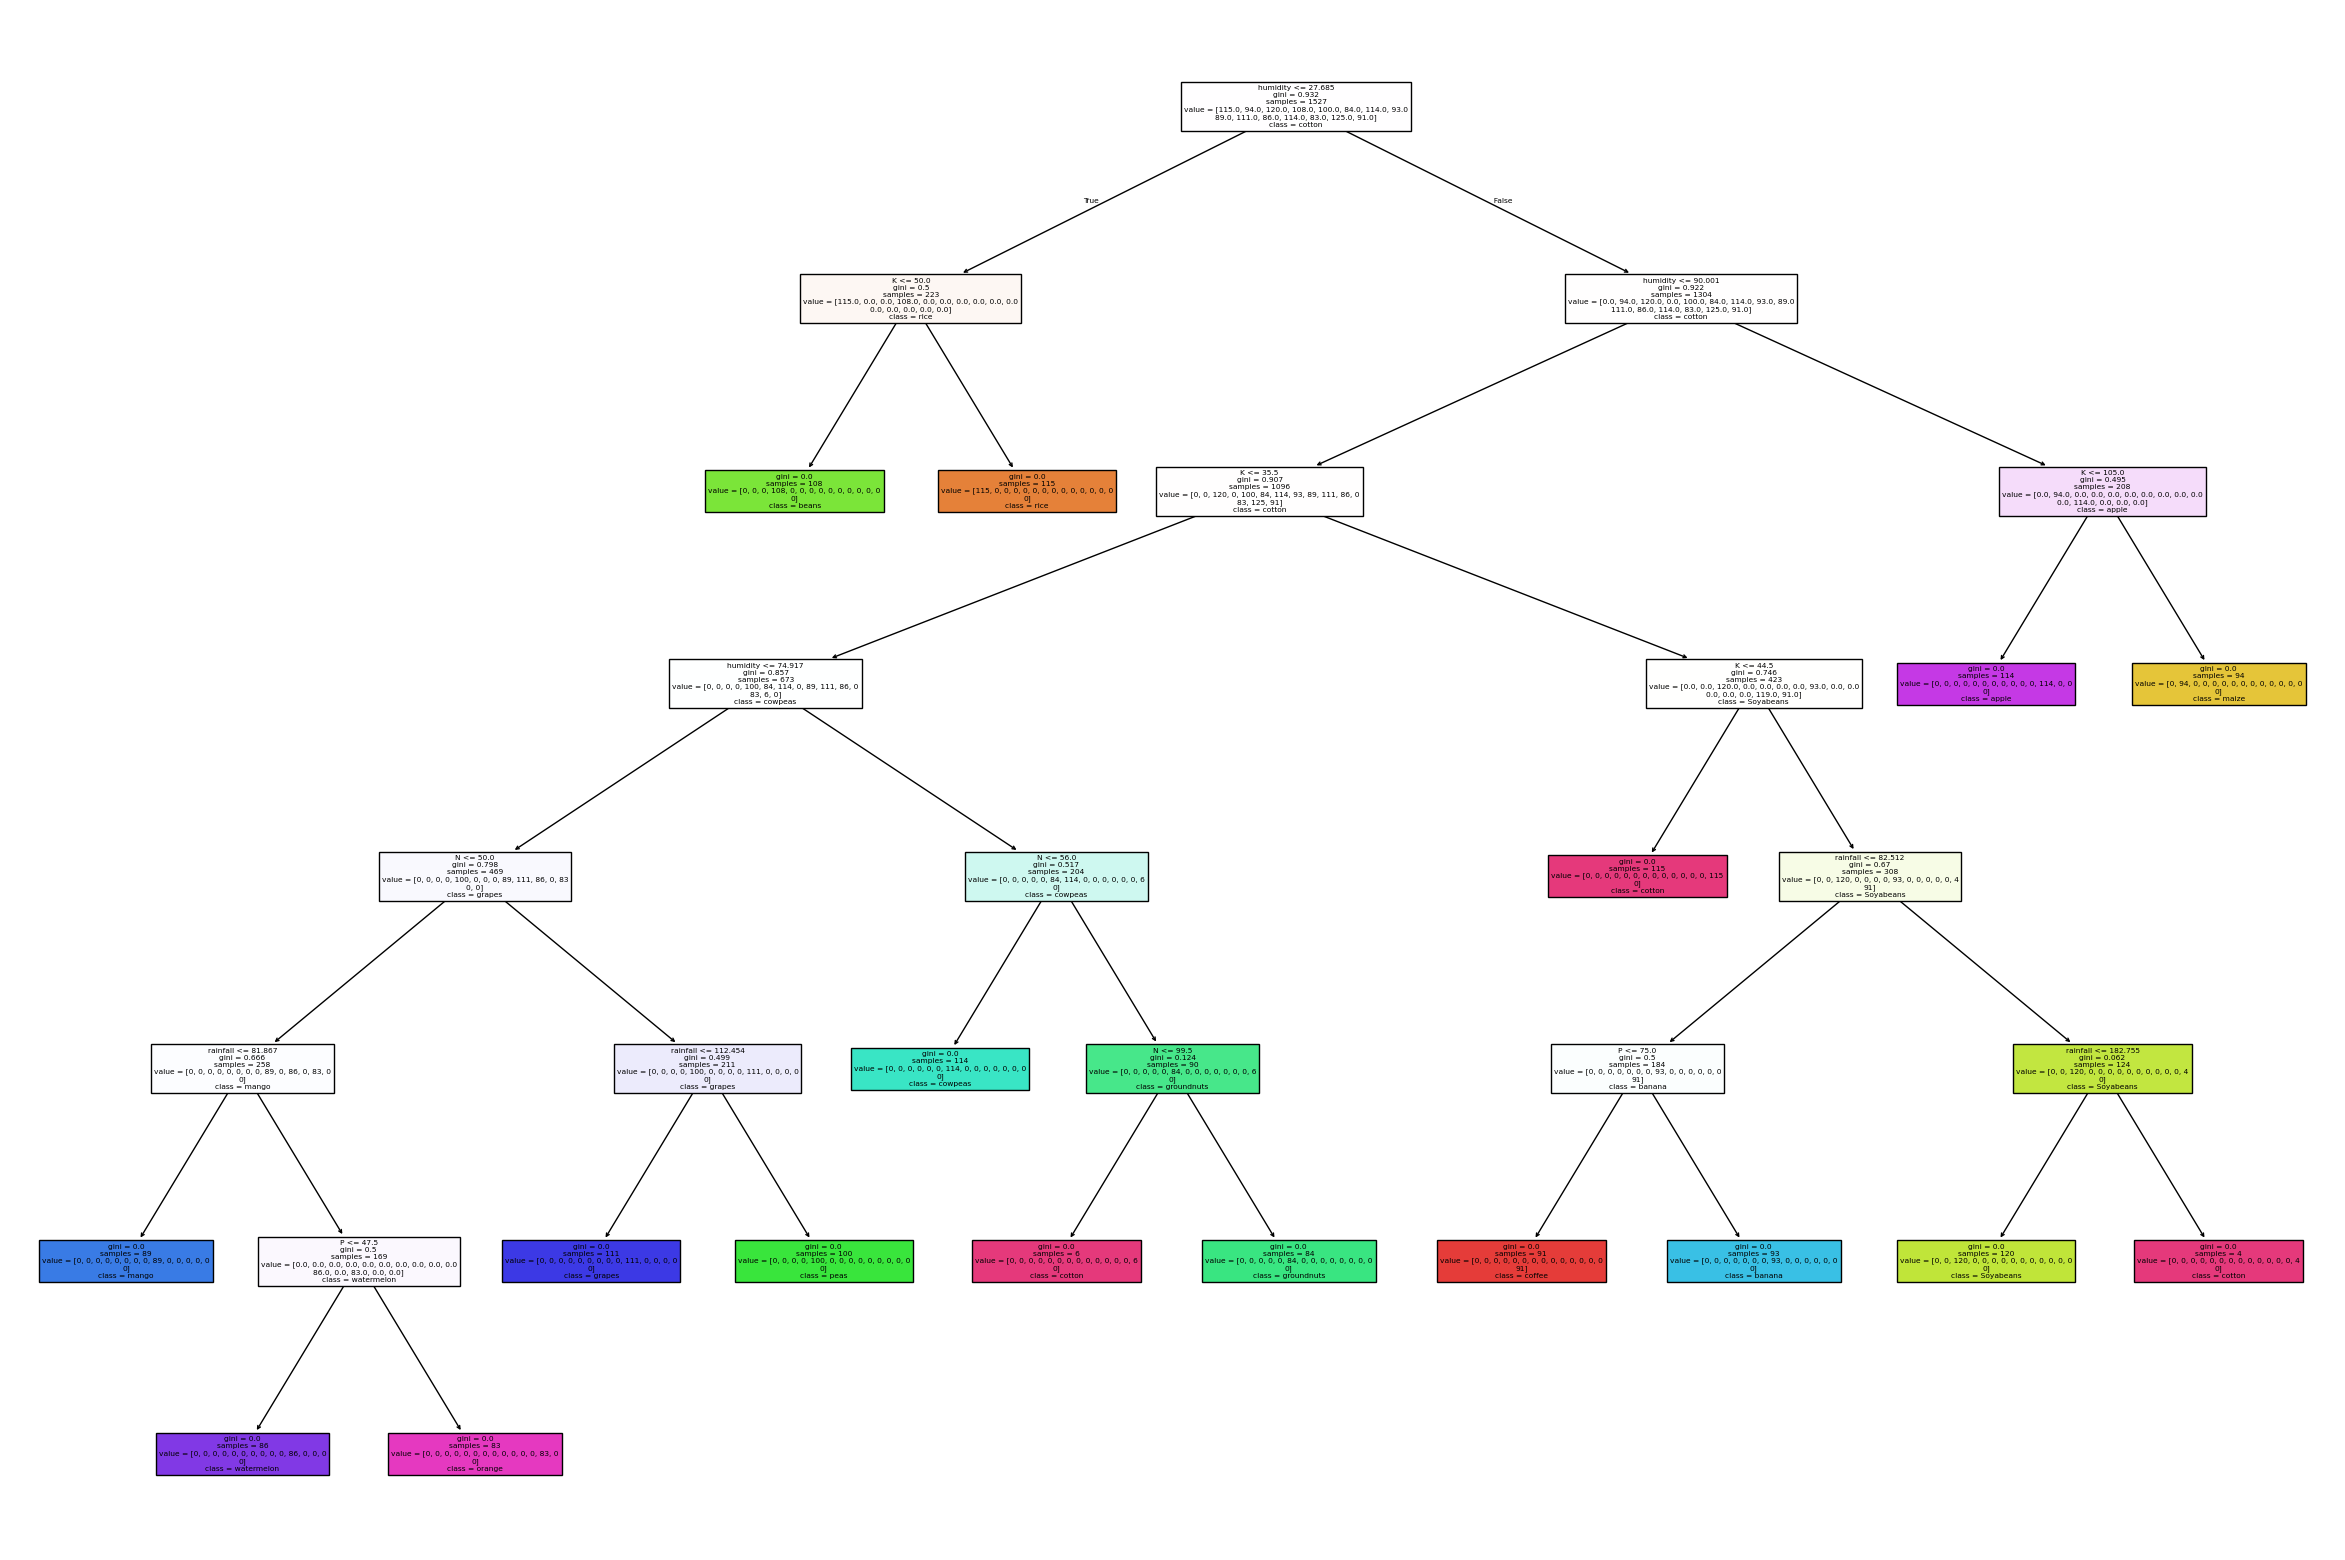

In [173]:
plt.figure(figsize=(30, 20))
plot_tree(tree_classification, filled=True, feature_names=list(X.columns), class_names=Y.unique())
plt.show()

In [174]:
# Visualizar a árvore de decisão em forma de texto
tree_text = export_text(tree_classification, feature_names=list(X.columns))
print(tree_text)

|--- humidity <= 27.69
|   |--- K <= 50.00
|   |   |--- class: beans
|   |--- K >  50.00
|   |   |--- class: Soyabeans
|--- humidity >  27.69
|   |--- humidity <= 90.00
|   |   |--- K <= 35.50
|   |   |   |--- humidity <= 74.92
|   |   |   |   |--- N <= 50.00
|   |   |   |   |   |--- rainfall <= 81.87
|   |   |   |   |   |   |--- class: groundnuts
|   |   |   |   |   |--- rainfall >  81.87
|   |   |   |   |   |   |--- P <= 47.50
|   |   |   |   |   |   |   |--- class: mango
|   |   |   |   |   |   |--- P >  47.50
|   |   |   |   |   |   |   |--- class: peas
|   |   |   |   |--- N >  50.00
|   |   |   |   |   |--- rainfall <= 112.45
|   |   |   |   |   |   |--- class: maize
|   |   |   |   |   |--- rainfall >  112.45
|   |   |   |   |   |   |--- class: coffee
|   |   |   |--- humidity >  74.92
|   |   |   |   |--- N <= 56.00
|   |   |   |   |   |--- class: cowpeas
|   |   |   |   |--- N >  56.00
|   |   |   |   |   |--- N <= 99.50
|   |   |   |   |   |   |--- class: rice
|   |   |   |  